### **Rectified linear unit activation function(ReLU)**

ReLU function formula and curve are as follows


$$ReLU(x)= max(x,0)$$

$$where\ ReLU(x) \in (0, x),\\
and\ x \in [-\infty, +\infty]$$





#### Python implimentation 

In [62]:
# python helper functions for plotting graphs -
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')

x = np.linspace(-10, 10, 100)

def plot_graph(x, y,
               ALPHA=0.6,
               label_x = r"$x \rightarrow$", label_y=r"$act(x) \rightarrow$",
               title=None,
               LABEL=None):
    plt.figure(figsize=(7,5))
    plt.axhline(y=0, color="black", linestyle="--", lw=2)
    plt.axvline(x=0, color="black", linestyle="--", lw=2)
    plt.xlabel(label_x)
    plt.ylabel(label_y)
    plt.title(title)

    if LABEL != None:
        plt.plot(x, y, alpha=ALPHA, label=LABEL)
        plt.legend(fontsize=14)
    else:
        plt.plot(x, y, alpha=ALPHA)

def derivative(f, x, delta_x=1e-6):
    return (f(x + delta_x) - f(x))/(delta_x)

In [63]:
def relu(x):
    return np.where(x>=0, x, 0)

#### Alternatively

```python
def relu(x):
    return np.where(x>=0, x, 0)
```


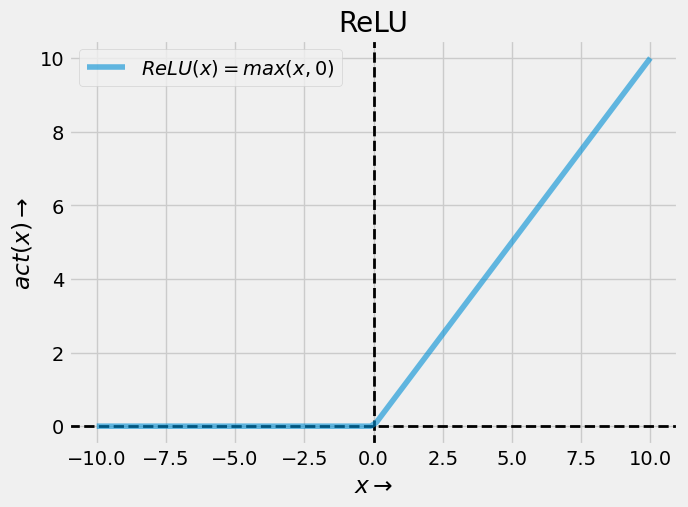

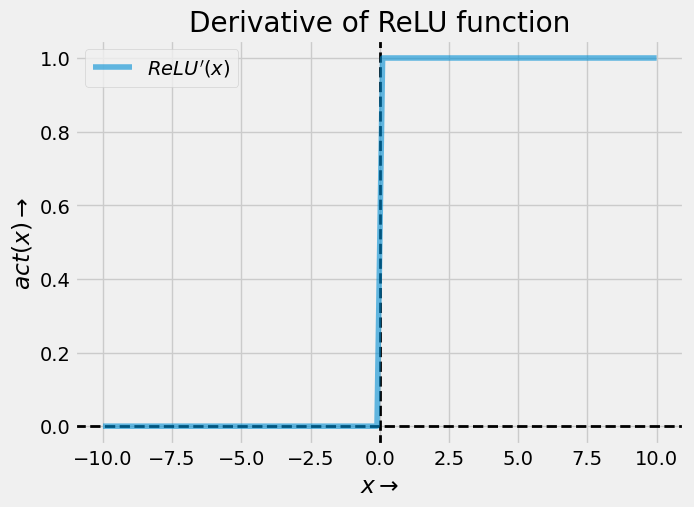

In [64]:
plot_graph(x, relu(x), title="ReLU",
           LABEL=r"$ReLU(x)= max(x,0)$");

plot_graph(x, derivative(relu, x), title="Derivative of ReLU function",
           LABEL=r"$ReLU^\prime(x)$")

The ReLU function is actually a function that takes the maximum value. Note that this is not fully interval-derivable, but we can take sub-gradient, as shown in the figure above. Although ReLU is simple, it is an important achievement in recent years.

The ReLU (Rectified Linear Unit) function is an activation function that is currently more popular. Compared with the sigmod function and the tanh function, it has the following advantages:

1. When the input is positive, there is no gradient saturation problem.

2. The calculation speed is much faster. The ReLU function has only a linear relationship (before and after 0 i.e. conditionally linear or piece wise linear). Whether it is forward or backward, it is much faster than sigmod and tanh. (Sigmod and tanh need to calculate the exponent, which will be slower.)

Of course, there are disadvantages:

1. When the input is negative, ReLU is completely inactive, which means that once a negative number is entered, ReLU will die. In this way, in the forward propagation process, it is not a problem. Some areas are sensitive and some are insensitive. But in the backpropagation process, if you enter a negative number, the gradient will be completely zero, which has the same problem as the sigmod function and tanh function.

2. We find that the output of the ReLU function is either 0 or a positive number, which means that the ReLU function is not a 0-centric function.

### **Leaky ReLU function**

$$
leaky\_relu(x, \alpha) = \left\{\begin{matrix}
x & x\geq 0 \\
\alpha x & x \lt 0
\end{matrix}\right.
$$

$$where\ x \in [-\infty, +\infty]$$

#### Python implimentation -

In [65]:
def leaky_relu(x, alpha=0.3):
    return np.where(x>=0, x, alpha*x)

In [66]:
# tf.keras.layers.LeakyReLU

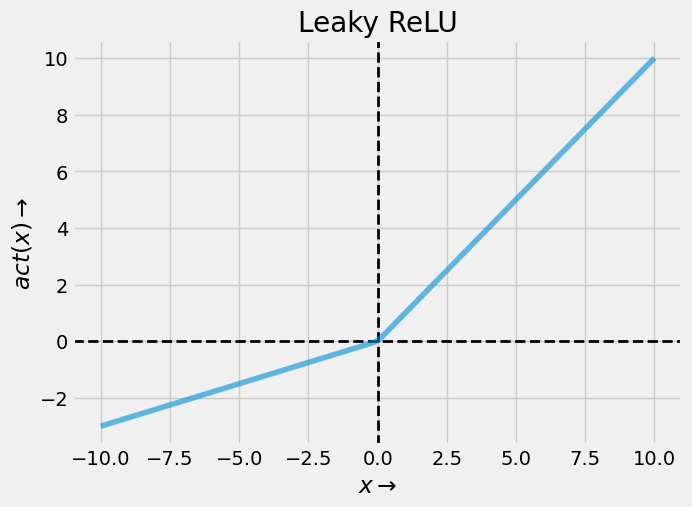

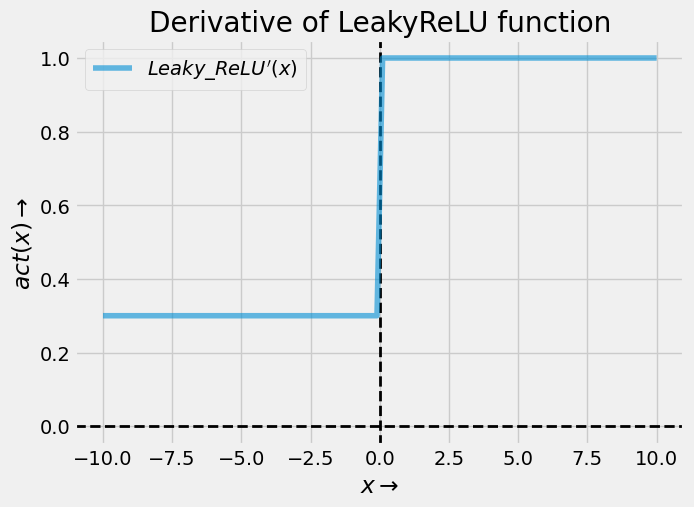

In [67]:
plot_graph(x, leaky_relu(x), title="Leaky ReLU");

plot_graph(x, derivative(leaky_relu, x), title="Derivative of LeakyReLU function",
           LABEL=r"$Leaky\_ReLU^\prime(x)$")


In order to solve the Dead ReLU Problem, people proposed to set the first half of ReLU 0.01x instead of 0. Another intuitive idea is a parameter-based method, **$Parametric ReLU : f(x)= max(\alpha x,x)$**, WHERE $\alpha$ can be learned from back propagation. In theory, Leaky ReLU has all the advantages of ReLU, plus there will be no problems with Dead ReLU, but in actual operation, it has not been fully proved that Leaky ReLU is always better than ReLU.

### **ELU (Exponential Linear Units) function**

$$elu(x, \alpha) = \left\{\begin{matrix} x & x\geq0\\ \alpha \cdot (e^{x} - 1) & x \lt 0 \end{matrix}\right.$$

$$\alpha\ = scaler\ slope\ of\ negative\ section$$

#### Python implimentation -

In [68]:
def elu(x, ALPHA=1.0):
    return np.where(x > 0, x, ALPHA * (np.exp(x) - 1))


#### Alternatively

```python
def elu(x, ALPHA=1.0):
    return np.where(x>0, x, (ALPHA * (np.exp(x) - 1)))
```

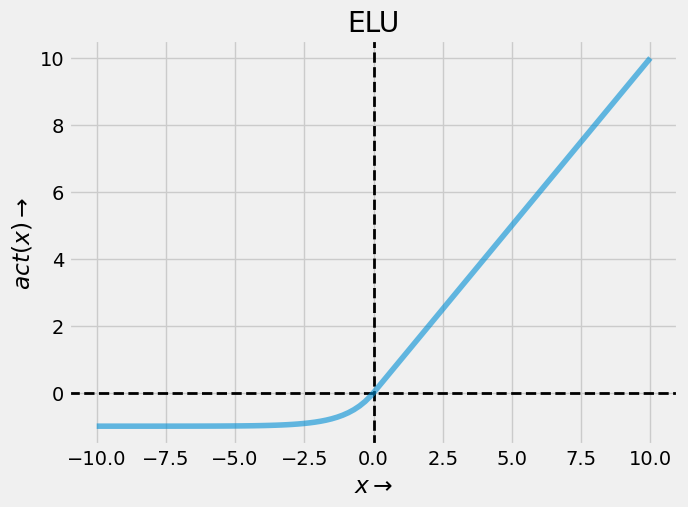

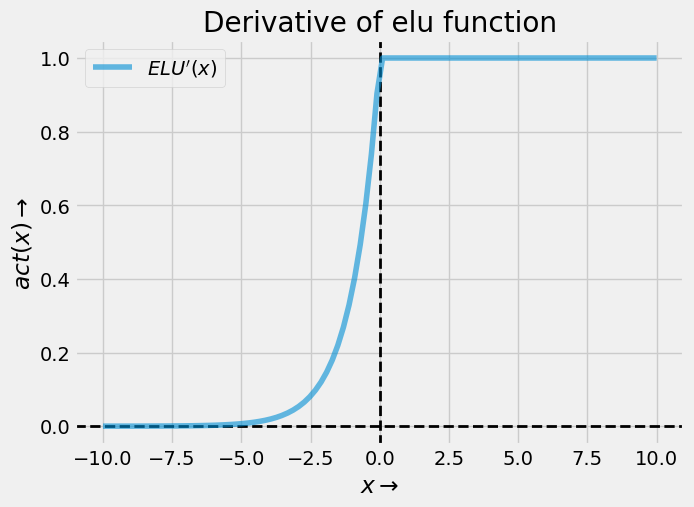

In [69]:
plot_graph(x, elu(x), title="ELU");

plot_graph(x, derivative(elu, x), title="Derivative of elu function",
           LABEL=r"$ELU^\prime(x)$")


ELU is also proposed to solve the problems of ReLU. Obviously, ELU has all the advantages of ReLU, and:

* No Dead ReLU issues
* The mean of the output is close to 0, zero-centered

One small problem is that it is slightly more computationally intensive. Similar to Leaky ReLU, although theoretically better than ReLU, there is currently no good evidence in practice that ELU is always better than ReLU.

### SELU:

scale * elu(x, alpha)


[reference](https://www.tensorflow.org/api_docs/python/tf/keras/activations/selu)

In [70]:

def selu(x, ALPHA=1.0):
    return 1.05070098 * np.where(x > 0, x, 1.67326324 * (np.exp(x) - 1))


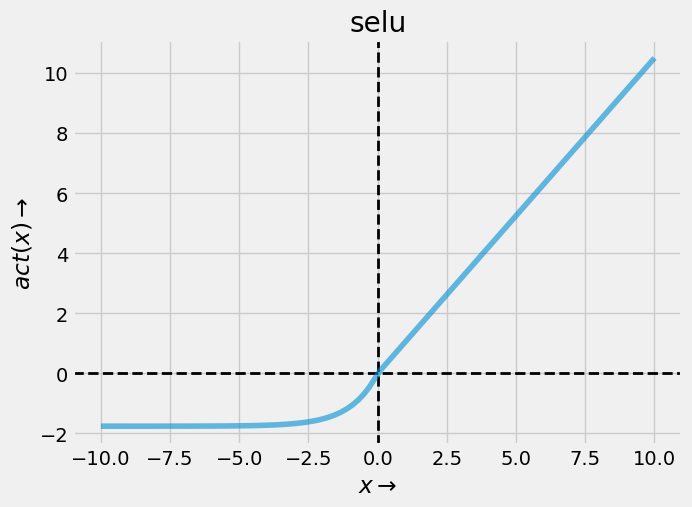

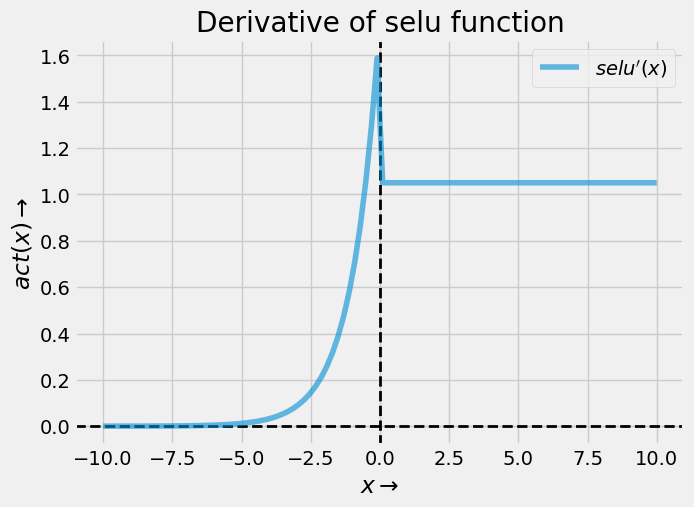

In [71]:
plot_graph(x, selu(x), title="selu");

plot_graph(x, derivative(selu, x), title="Derivative of selu function",
           LABEL=r"$selu^\prime(x)$")

In [72]:

def selu_alt(x, ALPHA=1.67326324, scale=1.05070098):
    return np.where(x > 0, x, ALPHA * (np.exp(x) - 1))


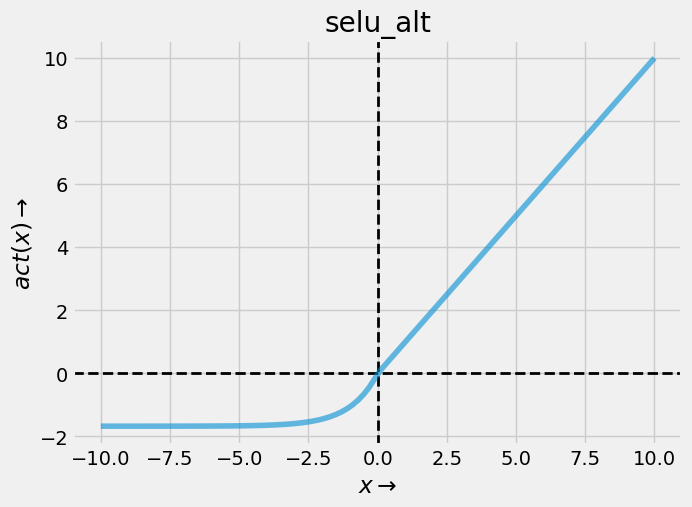

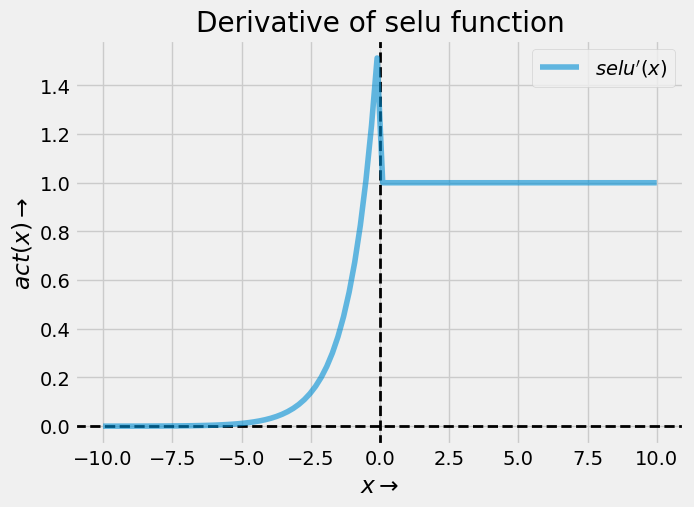

In [73]:
plot_graph(x, selu_alt(x), title="selu_alt");

plot_graph(x, derivative(selu_alt, x), title="Derivative of selu function",
           LABEL=r"$selu^\prime(x)$")

### **PRelu (Parametric ReLU)**

PReLU is also an improved version of ReLU. In the negative region, PReLU has a small slope, which can also avoid the problem of ReLU death. Compared to ELU, PReLU is a linear operation in the negative region. Although the slope is small, it does not tend to 0, which is a certain advantage.

$$f(y_i) = \left\{\begin{matrix} y_i & y_i>0\\ \alpha_i \cdot y_i & y_i \leq 0 \end{matrix}\right.$$

We look at the formula of PReLU. The parameter α is generally a number between 0 and 1, and it is generally relatively small, such as a few zeros. When α = 0.01, we call PReLU as Leaky Relu , it is regarded as a special case PReLU it.

Above, yᵢ is any input on the ith channel and aᵢ is the negative slope which is a learnable parameter.
* if $\alpha_i=0$, f becomes ReLU
* if $\alpha_i>0$, f becomes leaky ReLU
* if $\alpha_i$ is a learnable parameter, f becomes PReLU